# CNN para classificação de dígitos MNIST e preparação dos parâmetros para FPGA

Projeto **CI Digital — Grupo 1**  
Notebook original: **Hyago Vieira Lemes Barbosa Silva**

Este notebook treina uma rede neural convolucional (CNN) para reconhecer dígitos manuscritos de `0` a `9` e prepara seus pesos e vieses para uma futura implementação em FPGA.

Ao final, os parâmetros são:

1. treinados em ponto flutuante com PyTorch;
2. quantizados para **8 bits em ponto fixo Q1.7**;
3. codificados em **complemento de dois**;
4. exportados como arquivos de inicialização de memória `.mem`.

> **Escopo importante:** este notebook prepara e valida os dados do modelo. Ele não contém, por si só, o circuito RTL em Verilog/VHDL, a síntese, o bitstream nem a medição em uma placa FPGA.

## 1. Visão geral para quem está começando

- **IA de classificação:** recebe uma imagem e escolhe uma entre dez classes: `0`, `1`, ..., `9`.
- **CNN:** tipo de rede neural apropriada para imagens. Suas convoluções aprendem pequenos filtros que respondem a formas como bordas e curvas.
- **Treinamento:** etapa executada no computador, na qual os pesos do modelo são ajustados usando exemplos do MNIST.
- **Inferência:** uso do modelo já treinado para classificar uma nova imagem. Essa é a etapa que se pretende levar para a FPGA.
- **FPGA:** circuito digital reconfigurável. Em vez de executar diretamente as operações de ponto flutuante do PyTorch, normalmente usa aritmética inteira/ponto fixo e memórias internas.

Fluxo deste projeto:

`MNIST → treinamento em PyTorch → teste em software → quantização Q1.7 → .mem → futura integração com RTL → FPGA`

## 2. O que já está pronto e o que ainda falta

| Etapa | Situação neste notebook |
|---|---|
| Baixar e preparar o MNIST | Implementada |
| Treinar e avaliar a CNN em `float32` | Implementada |
| Salvar checkpoint do modelo | Implementada |
| Quantizar pesos e vieses para 8 bits Q1.7 | Implementada |
| Gerar `.mem` hexadecimal | Implementada |
| Simular toda a inferência com aritmética inteira | Pendente |
| Implementar convolução, pooling, ReLU e camada final em RTL | Pendente |
| Sintetizar, gerar bitstream e testar em uma FPGA | Pendente |

Essa separação evita uma confusão comum: **gerar os pesos para memória não é o mesmo que implementar toda a rede na FPGA**.

## 3. Dependências

Ambiente recomendado:

- Python 3.10 ou superior;
- PyTorch e torchvision;
- NumPy;
- Matplotlib;
- Pillow;
- Jupyter Notebook ou JupyterLab.

Instalação básica:

```bash
pip install torch torchvision numpy matplotlib pillow jupyter
```


In [36]:
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import pyplot


Ignorando avisos do terminal

In [37]:
import warnings
warnings.filterwarnings('ignore')

## 4. Configuração e reprodutibilidade

A semente fixa reduz variações entre execuções.

In [38]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 5. Base de dados MNIST

O MNIST contém **70.000 imagens** em tons de cinza, cada uma com `28 × 28` pixels:

- 60.000 imagens para treinamento;
- 10.000 imagens para teste;
- 10 classes, correspondentes aos dígitos de `0` a `9`.

`transforms.ToTensor()` converte cada pixel do intervalo inteiro `0…255` para um valor de ponto flutuante no intervalo `0…1` e organiza a imagem no formato `[canal, altura, largura]`.

In [39]:
# MNIST Dataset 
train_dataset = datasets.MNIST(
    root='./data/',
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

test_dataset = datasets.MNIST(
    root='./data/',
    train=False,
    transform=transforms.ToTensor()
)

print(f"Treinamento: {len(train_dataset)} imagens")
print(f"Teste: {len(test_dataset)} imagens")

100.0%
100.0%
100.0%
100.0%

Treinamento: 60000 imagens
Teste: 10000 imagens


### Lotes de dados

Em vez de processar as 60.000 imagens de uma só vez, o treinamento usa lotes (*batches*) de 64 imagens. O embaralhamento é ativado somente no conjunto de treinamento.

In [40]:
# Data Loader (Input pipeline)
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True
)

test_loader = torch.utils.data.DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    shuffle = False
)

## 6. Arquitetura da CNN

A rede é deliberadamente pequena para facilitar uma implementação futura em hardware.

| Etapa | Entrada → saída | Parâmetros treináveis | Função |
|---|---:|---:|---|
| Convolução 1, 3 filtros `5×5` | `1×28×28 → 3×24×24` | 78 | Extrair padrões simples |
| Max pooling `2×2` + ReLU | `3×24×24 → 3×12×12` | 0 | Reduzir o mapa e remover valores negativos |
| Convolução 2, 3 filtros `5×5` | `3×12×12 → 3×8×8` | 228 | Combinar padrões da primeira camada |
| Max pooling `2×2` + ReLU | `3×8×8 → 3×4×4` | 0 | Reduzir novamente |
| Flatten | `3×4×4 → 48` | 0 | Transformar os mapas em um vetor |
| Camada totalmente conectada | `48 → 10` | 490 | Gerar uma pontuação para cada dígito |

**Total: 796 parâmetros treináveis.** Uma inferência executa aproximadamente **58.080 operações de multiplicação e acumulação (MACs)**, desconsiderando pooling e ativações.

O `log_softmax` é usado apenas para calcular a perda no treinamento. Na FPGA, para escolher a classe, basta localizar o maior dos 10 valores de saída (*argmax*); não é obrigatório implementar softmax.

### Diagrama original da arquitetura

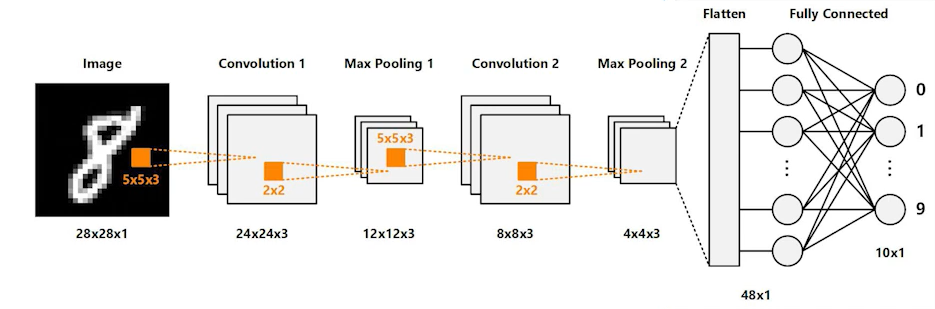

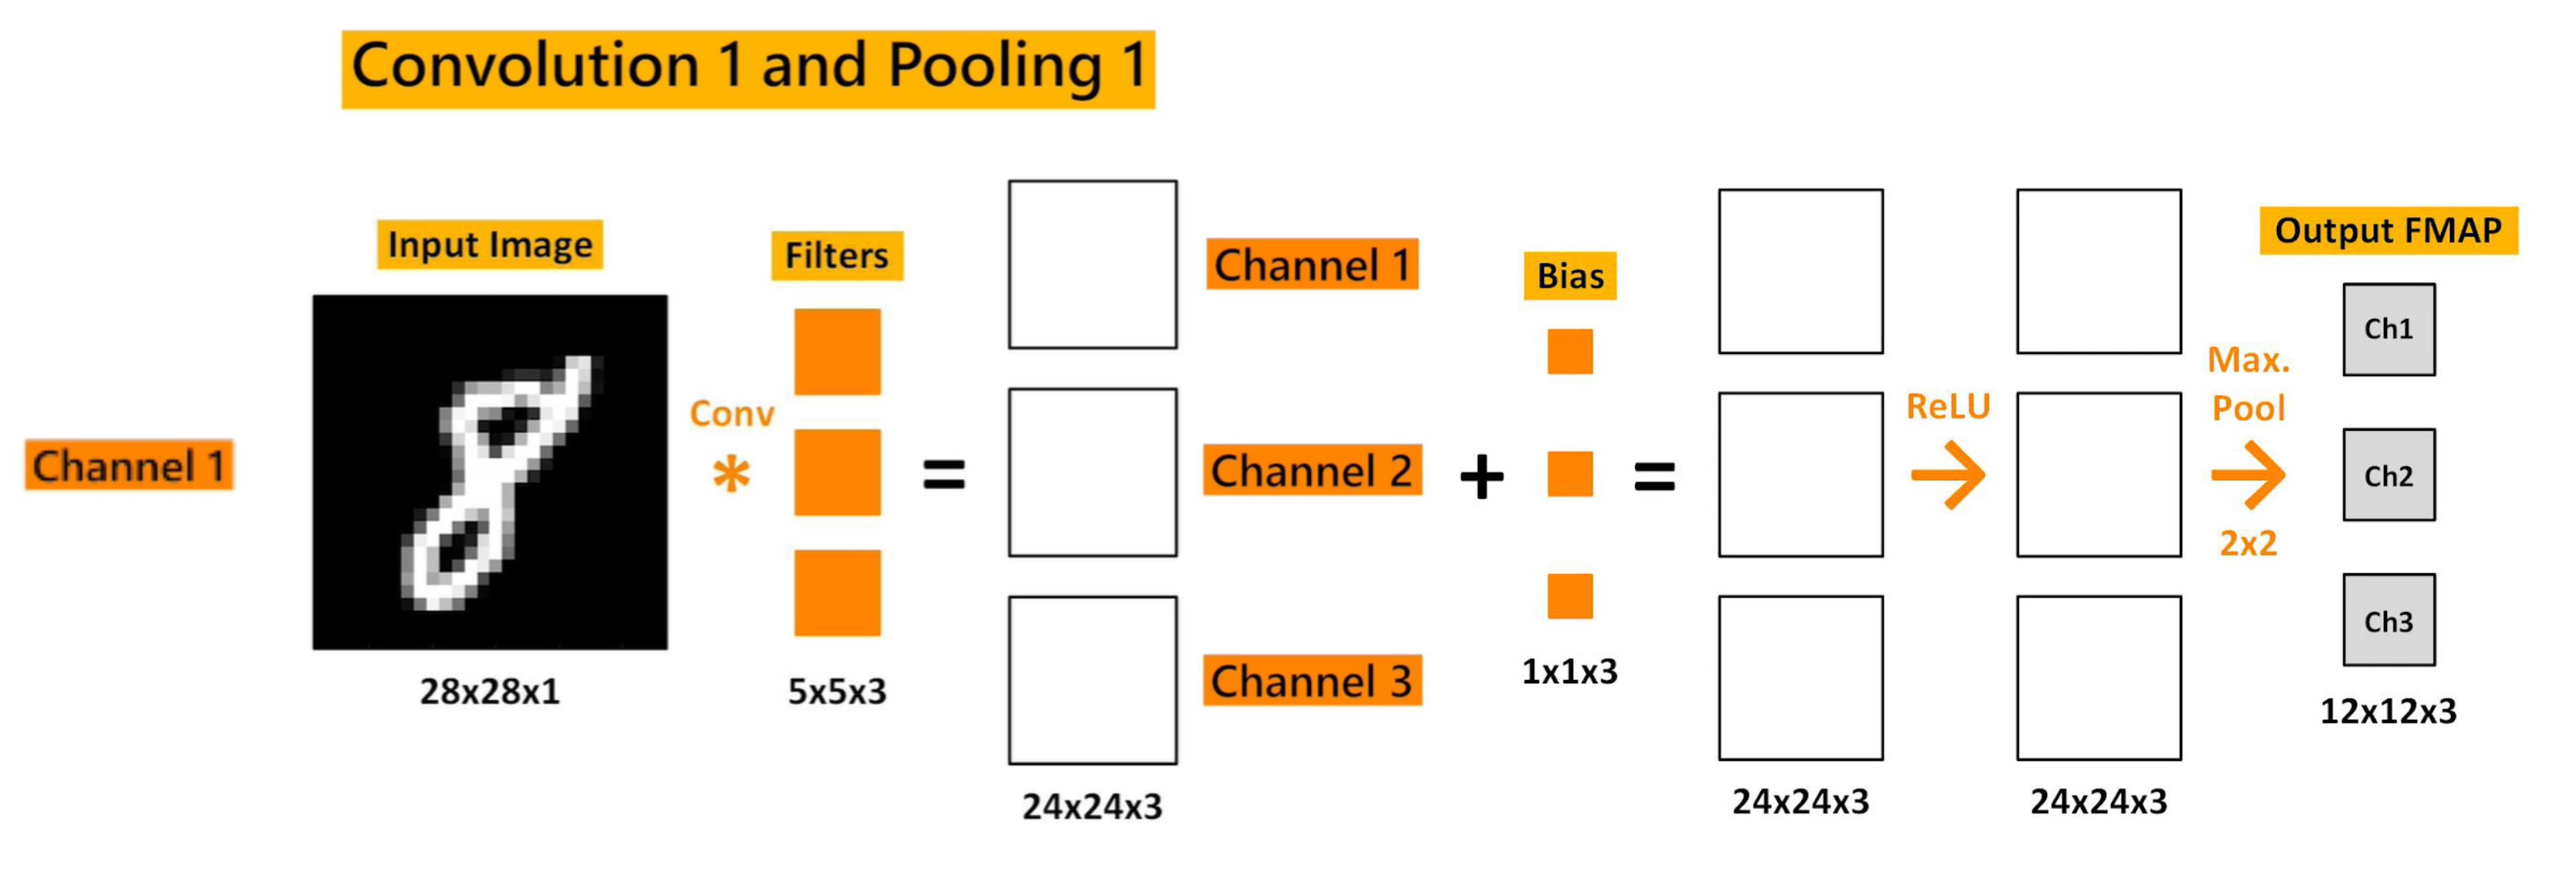

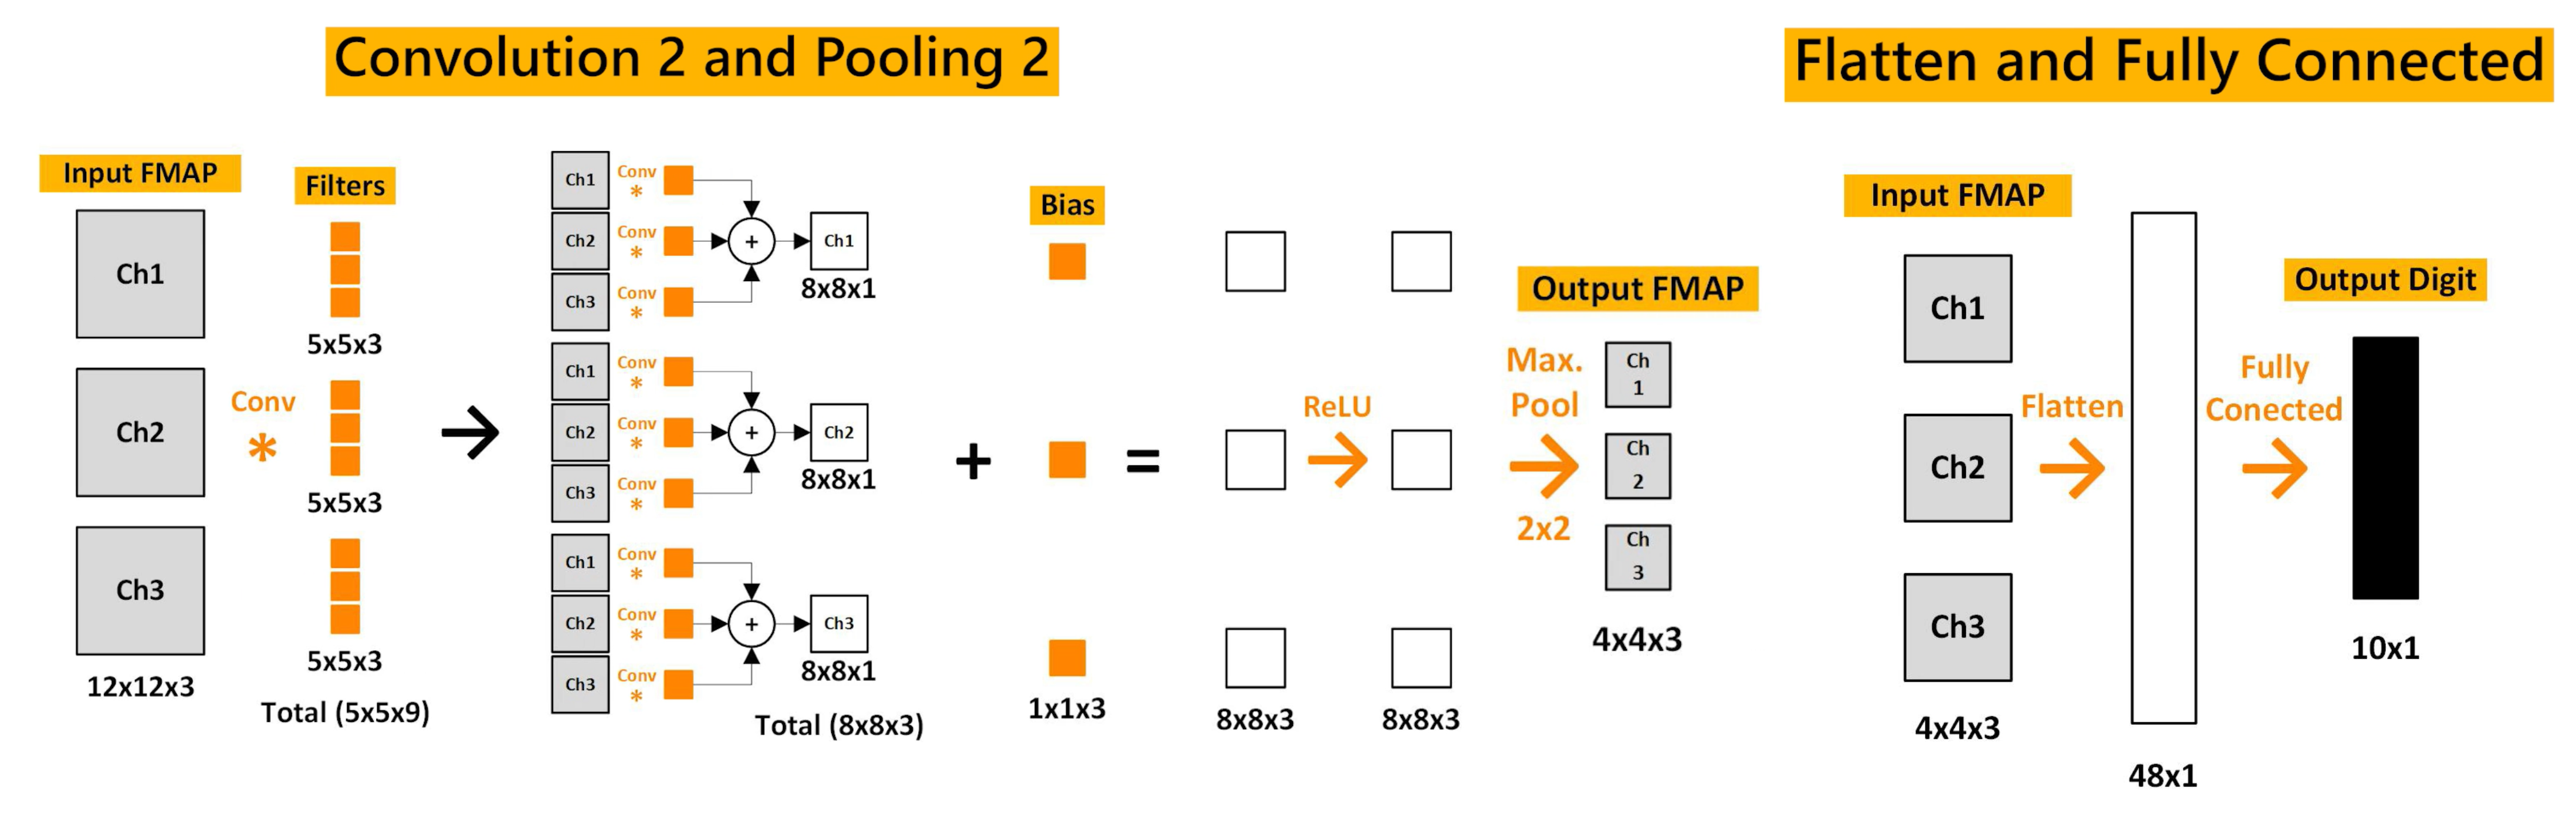

### Calculo do número de parâmetros treináveis

1. Camada de convolução 1:
   5x5x3(kernel e canais) + 1x3(bias) = 78

2. Camada de convolução 2:
    5x5x9 + 1x3 = 228

3. Camada totalmente conectada:
    48x10 + 1x10 = 490
   
resultando em:

Total de parâmetros treináveis = 78 + 228 + 490 = 796


In [ ]:
# CNN class
class CNN(nn.Module):
     # Initialization
    def __init__(self):
        super (CNN, self).__init__()
        
        # Arrays serão usados para debuging por propósito
        self.conv1_out_np = np.zeros((1, 3, 24, 24))
        self.mp1_out_np = np.zeros((1, 3, 12, 12))
        self.conv2_out_np = np.zeros((1, 3, 8, 8))
        self.mp2_out_np = np.zeros((1, 3, 4, 4))
        self.fc_in_np = np.zeros((1, 48))
        self.fc_out_np = np.zeros((1, 10))
        
        # 1 camada de convolução
        # input shape ou entrada da rede -> (28, 28, 1)
        # camada de convolução -> (24, 24, 3)
        # Max pooling de camada -> (12, 12, 3)
        self.conv1 = nn.Conv2d(1, 3, kernel_size=5)
        
        # 2 camada de convolução
        # input shape ou entrada da rede -> (12, 12, 3)
        # camada de convolução -> (8, 8, 3)
        # Max pooling de camada -> (4, 4, 3)
        self.conv2 = nn.Conv2d(3, 3, kernel_size=5)
        
        # Max pooling de camada
        self.mp = nn.MaxPool2d(2)
        
        # camada totalmente conectada ou fully connected layer
        # número de pesos = 480
        self.fc_1 = nn.Linear(48, 10)
        
    def forward(self, x):
        
        in_size = x.size(0)
        
        # Camada de integração 
        x = self.conv1(x)
        self.conv1_out_np = x.detach().numpy()
        
        x = F.relu(self.mp(x))
        self.mp1_out_np = x.detach().numpy()

        x = self.conv2(x)
        self.conv2_out_np = x.detach().numpy()
        
        x = F.relu(self.mp(x))
        self.mp2_out_np = x.detach().numpy()
        
        # Camada de achatamento ou Flatten -> vetorização
        x = x.view(in_size, -1)
        self.fc_in_np = x.detach().numpy()
        
        # Camada totalmente conectada Fully Connected Layer
        x = self.fc_1(x)
        self.fc_out_np = x.detach().numpy()
        
        return F.log_softmax(x)

visualizando modelo

In [42]:
model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 3, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
  (mp): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc_1): Linear(in_features=48, out_features=10, bias=True)
)


## 7. Treinamento e avaliação

O treinamento usa **SGD com momentum**. Em cada lote:

1. a rede calcula uma previsão;
2. a função de perda mede o erro;
3. a retropropagação calcula os gradientes;
4. o otimizador atualiza pesos e vieses.

A função de teste desativa o cálculo de gradientes, pois os parâmetros não são alterados durante a avaliação.

In [43]:
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.5
)

Treinamento do modelo

In [44]:
def train(epoch):
    model.train()
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = Variable(data), Variable(target)
        
        optimizer.zero_grad()
        
        # Saída de realimentação
        output = model(data)
        
        # calibração do erro Loss
        loss = F.nll_loss(output, target)
        
        # Gradient
        loss.backward()
        
        # Back propagation - retropropagação
        optimizer.step()
        
        if batch_idx % 10 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()
            ))

In [45]:
def test():
    model.eval()
    
    test_loss = 0
    correct = 0
    
    for data, target in test_loader:
        data, target = Variable(data, volatile=True), Variable(target)
        
        output = model(data)
        
        test_loss += F.nll_loss(output, target, size_average=False).item()
        
        pred = output.data.max(1, keepdim=True)[1]
        correct += pred.eq(target.data.view_as(pred)).cpu().sum()
    
    test_loss /= len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

Loop de treinamento verificando o andamento 

In [19]:
for epoch in range(1,10):
    train(epoch)
    test()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.321716
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.321233
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.319599
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.328754
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.319272
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.311427
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.297446
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.306854
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.325848
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.319732
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.314398
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.300914
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.322932
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.293293
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.286971
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.291559
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.303189
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.318104
Train Epoch: 1 [11520/60000 (19%)]	Loss: 2.300614
Train Epoch: 1 [12160/60000 (20%)]	Loss: 2.301561
Train Epoch: 1 [12800/60000 (

## 8. Salvamento e recarga do modelo

In [64]:
torch.save(model, "cnn_mnist.pt")

Criando a pasta `model/` e movendo arquivo cnn_mnist.pt para o diretório do modelo

In [65]:
!mkdir ./model
!mv  cnn_mnist.pt ./model/

Carregando modelo e validando 

In [53]:
model = torch.load("./model/cnn_mnist.pt", weights_only=False)
model.eval()
print(model)

CNN(
  (conv1): Conv2d(1, 3, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
  (mp): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc_1): Linear(in_features=48, out_features=10, bias=True)
)


In [54]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Número de parâmetros: {total_params}")

Número de parâmetros: 796



## 9. Teste de uma imagem

Primeiro usamos uma imagem do próprio conjunto de teste. Isso deixa o exemplo reproduzível e evita depender de um arquivo externo que pode não existir.

Testando usando Bitmap Image, basicamente classificando o digito atraves de .bmp image

- 1° visualizando a imagem do teste real 
- 2° predizendo o resultado sobre a imagem

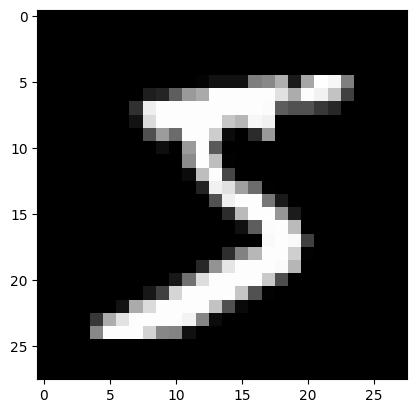

In [55]:
from PIL import Image

img = Image.open("./test/train_0.bmp", "r")
np_img = np.array(img)
plt.imshow(np_img, cmap=pyplot.get_cmap('gray'))

In [56]:

def sample_test():
    model.eval()
    
    test_loss = 0
    correct = 0
    
    target = Variable(torch.tensor([0]))
    
    # data (0_0.bmp)
    img = Image.open("./test/train_0.bmp", "r")
    np_img = np.array(img)
    np_img_re = np.reshape(np_img, (1,1,28,28))
    
    # 0 - 255 -> 0 - 1 np.array -> tensor
    data = Variable(torch.tensor((np_img_re / 255), dtype = torch.float32))
    
    output = model(data)
    
    test_loss += F.nll_loss(output, target, reduction='sum').item()
    
    pred = output.data.max(1, keepdim=True)[1]
    print('Predict output: ' + ', '.join(map(str, pred.flatten().tolist())))

sample_test()

Predict output: 5


## 10. Da rede treinada para uma futura implementação em FPGA

O PyTorch armazena os parâmetros em `float32`. Esse formato oferece boa precisão, mas consome 32 bits por valor e exige uma aritmética mais cara em hardware.

Este projeto usa **Q1.7**, uma representação de ponto fixo de 8 bits:

- 1 bit representa o sinal;
- 7 bits representam a parte fracionária;
- escala: `2⁷ = 128`;

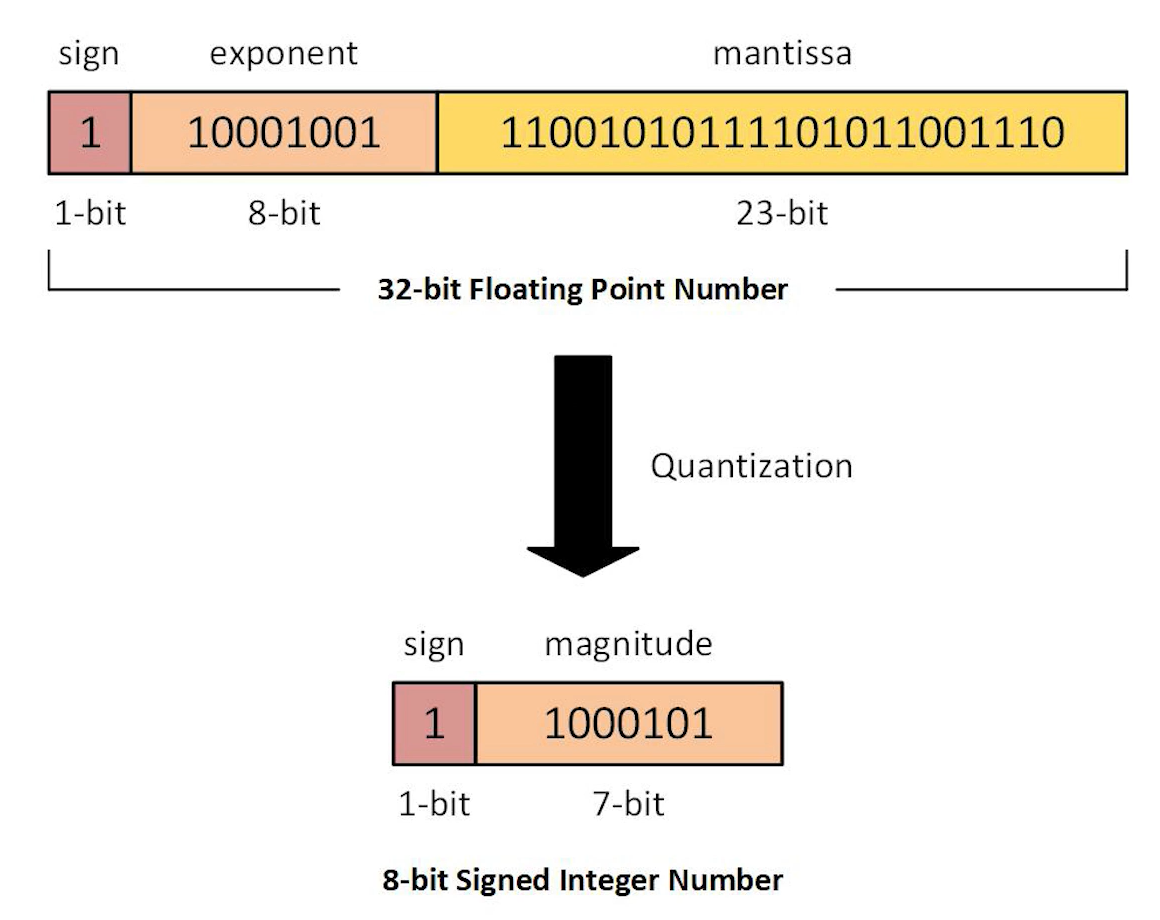


In [57]:
print(np.shape(model.conv1.weight))

torch.Size([3, 1, 5, 5])


In [58]:
# Weights & Bias em hexadecimal para camada de convolução 1 Layer1

# Calibração
# 7 bits -> 2^7 = 128
int_conv1_weight_1 = torch.tensor((model.conv1.weight.data[0][0] * 128), dtype = torch.int32)
int_conv1_weight_2 = torch.tensor((model.conv1.weight.data[1][0] * 128), dtype = torch.int32)
int_conv1_weight_3 = torch.tensor((model.conv1.weight.data[2][0] * 128), dtype = torch.int32)
int_conv1_bias = torch.tensor((model.conv1.bias.data * 128), dtype = torch.int32)

print("Signed")
print(int_conv1_weight_1)
print(int_conv1_weight_2)
print(int_conv1_weight_3)
print(int_conv1_bias)

# Complemento 2
for i in range(5):
    for j in range(5):
        if int_conv1_weight_1[i][j] < 0:
            int_conv1_weight_1[i][j] += 256
        if int_conv1_weight_2[i][j] < 0:
            int_conv1_weight_2[i][j] += 256
        if int_conv1_weight_3[i][j] < 0:
            int_conv1_weight_3[i][j] += 256

for k in range(3):
    if int_conv1_bias[k] < 0:
        int_conv1_bias[k] += 256

print("Unsigned")
print(int_conv1_weight_1)
print(int_conv1_weight_2)
print(int_conv1_weight_3)
print(int_conv1_bias)

np.savetxt('conv1_weight_1.mem', int_conv1_weight_1, fmt='%1.2x',delimiter = " ")
np.savetxt('conv1_weight_2.mem', int_conv1_weight_2, fmt='%1.2x',delimiter = " ")
np.savetxt('conv1_weight_3.mem', int_conv1_weight_3, fmt='%1.2x',delimiter = " ")
np.savetxt('conv1_bias.mem', int_conv1_bias, fmt='%1.2x',delimiter = " ")

Signed
tensor([[-24, -22, -14,  44, 113],
        [ -9, -43, -27,  52,  71],
        [-27, -45, -32,  73,  77],
        [-52, -45,  14,  80,  64],
        [-21,  24,  53,  84,  21]], dtype=torch.int32)
tensor([[-23,  -6,   3,  17,   0],
        [ 11, -20, -11,   1, -20],
        [-18,   6, -22,  -9,  28],
        [-18, -15, -10,  28,  -1],
        [ 14, -16,  18,  22, -11]], dtype=torch.int32)
tensor([[ 25,   9,  19,  30,  29],
        [ 34,  74,  83,  74,  25],
        [ 56,  62,  88,  25,  23],
        [ -4,   6,  28,  37,  60],
        [-49, -20,   4,   1,  50]], dtype=torch.int32)
tensor([-99, -13,  12], dtype=torch.int32)
Unsigned
tensor([[232, 234, 242,  44, 113],
        [247, 213, 229,  52,  71],
        [229, 211, 224,  73,  77],
        [204, 211,  14,  80,  64],
        [235,  24,  53,  84,  21]], dtype=torch.int32)
tensor([[233, 250,   3,  17,   0],
        [ 11, 236, 245,   1, 236],
        [238,   6, 234, 247,  28],
        [238, 241, 246,  28, 255],
        [ 14, 240,  1

Faremos a mesma coisa para convolução da camada 2

In [59]:
print(np.shape(model.conv2.weight))

torch.Size([3, 3, 5, 5])


In [60]:
# Weights & Bias em hexadecimal para camada de convolução 2 Layer2

# Calibração
# print(np.shape(model.conv2.weight))
int_conv2_weight_11 = torch.tensor((model.conv2.weight.data[0][0]* 128), dtype = torch.int32)
int_conv2_weight_12 = torch.tensor((model.conv2.weight.data[0][1]* 128), dtype = torch.int32)
int_conv2_weight_13 = torch.tensor((model.conv2.weight.data[0][2]* 128), dtype = torch.int32)

int_conv2_weight_21 = torch.tensor((model.conv2.weight.data[1][0] * 128), dtype = torch.int32)
int_conv2_weight_22 = torch.tensor((model.conv2.weight.data[1][1] * 128), dtype = torch.int32)
int_conv2_weight_23 = torch.tensor((model.conv2.weight.data[1][2] * 128), dtype = torch.int32)

int_conv2_weight_31 = torch.tensor((model.conv2.weight.data[2][0] * 128), dtype = torch.int32)
int_conv2_weight_32 = torch.tensor((model.conv2.weight.data[2][1] * 128), dtype = torch.int32)
int_conv2_weight_33 = torch.tensor((model.conv2.weight.data[2][2] * 128), dtype = torch.int32)

int_conv2_bias = torch.tensor((model.conv2.bias.data * 128), dtype = torch.int32)

print ("Signed")
print(int_conv2_weight_11)
print(int_conv2_weight_12)
print(int_conv2_weight_13, '\n')

print(int_conv2_weight_21)
print(int_conv2_weight_22)
print(int_conv2_weight_23, '\n')

print(int_conv2_weight_31)
print(int_conv2_weight_32)
print(int_conv2_weight_33, '\n')

print(int_conv2_bias)

# 2's Complement
for i in range(5):
    for j in range(5):
        if int_conv2_weight_11[i][j] < 0:
            int_conv2_weight_11[i][j] += 256
        if int_conv2_weight_12[i][j] < 0:
            int_conv2_weight_12[i][j] += 256
        if int_conv2_weight_13[i][j] < 0:
            int_conv2_weight_13[i][j] += 256
            
        if int_conv2_weight_21[i][j] < 0:
            int_conv2_weight_21[i][j] += 256
        if int_conv2_weight_22[i][j] < 0:
            int_conv2_weight_22[i][j] += 256
        if int_conv2_weight_23[i][j] < 0:
            int_conv2_weight_23[i][j] += 256
            
        if int_conv2_weight_31[i][j] < 0:
            int_conv2_weight_31[i][j] += 256
        if int_conv2_weight_32[i][j] < 0:
            int_conv2_weight_32[i][j] += 256
        if int_conv2_weight_33[i][j] < 0:
            int_conv2_weight_33[i][j] += 256

for k in range(3):
    if int_conv2_bias[k] < 0:
        int_conv2_bias[k] += 256

print ("Unsigned")
print(int_conv2_weight_11)
print(int_conv2_weight_12)
print(int_conv2_weight_13, '\n')

print(int_conv2_weight_21)
print(int_conv2_weight_22)
print(int_conv2_weight_23, '\n')

print(int_conv2_weight_31)
print(int_conv2_weight_32)
print(int_conv2_weight_33, '\n')

print(int_conv2_bias)

np.savetxt('conv2_weight_11.mem', int_conv2_weight_11, fmt='%1.2x',delimiter = " ")
np.savetxt('conv2_weight_12.mem', int_conv2_weight_12, fmt='%1.2x',delimiter = " ")
np.savetxt('conv2_weight_13.mem', int_conv2_weight_13, fmt='%1.2x',delimiter = " ")

np.savetxt('conv2_weight_21.mem', int_conv2_weight_21, fmt='%1.2x',delimiter = " ")
np.savetxt('conv2_weight_22.mem', int_conv2_weight_22, fmt='%1.2x',delimiter = " ")
np.savetxt('conv2_weight_23.mem', int_conv2_weight_23, fmt='%1.2x',delimiter = " ")

np.savetxt('conv2_weight_31.mem', int_conv2_weight_31, fmt='%1.2x',delimiter = " ")
np.savetxt('conv2_weight_32.mem', int_conv2_weight_32, fmt='%1.2x',delimiter = " ")
np.savetxt('conv2_weight_33.mem', int_conv2_weight_33, fmt='%1.2x',delimiter = " ")

np.savetxt('conv2_bias.mem', int_conv2_bias, fmt='%1.2x',delimiter = " ")

Signed
tensor([[ 25, -29, -17, -26, -13],
        [ 29,  27,   6,   2,  12],
        [ 68,  85,  28,  17,   9],
        [ 42,  70,  16,   5,   0],
        [ -1,  39,  24,  19,  28]], dtype=torch.int32)
tensor([[ 13,   1,  -8,  15, -10],
        [  7,   0,   0,  14,  10],
        [  0,  -6,   3,   1,  14],
        [ 10,  -1,   0, -13,  14],
        [-10,  -3,   0,  -8,   5]], dtype=torch.int32)
tensor([[ -4,   0,  14,  12,  30],
        [ 47,  47, -11, -64, -37],
        [ 20,  31, -26, -79, -38],
        [ 23,  24, -34, -38, -36],
        [ 29,  -8,  -9, -20,  -4]], dtype=torch.int32) 

tensor([[  2,  21,  60,  59, -10],
        [  3,  71,  67,  35,  20],
        [ 47,  68,  22,  24,  12],
        [ 31,  41, -17, -25, -10],
        [  8,   2,  -4, -38, -24]], dtype=torch.int32)
tensor([[ 14,  -3,  17,  19,  -7],
        [ -2,   2,   6,  14,  -8],
        [-12,   0,   3,   8,  10],
        [ -7,   8,  -4,  -5,   3],
        [  5,   4,   4,  12,   0]], dtype=torch.int32)
tensor([[ -8, -4

Mesmo ponto para camada totalmente conectada que seria a ultima

In [63]:
print(np.shape(model.fc_1.weight))
print(np.shape(model.fc_1.bias))


torch.Size([10, 48])
torch.Size([10])


In [81]:
# Weights & Bias em hexadecimal para camada totalmente conectadao (ultima) Fully Connected Layer

print(np.shape(model.fc_1.weight))
print((model.fc_1.weight * 128).int())

print(np.shape(model.fc_1.bias))
print((model.fc_1.bias * 128).int())

int_fc_weight = (model.fc_1.weight * 128).int()
int_fc_bias = (model.fc_1.bias * 128).int()

# 2's Complement
for i in range(10):
    for j in range(48):
        if int_fc_weight[i][j] < 0 :
            int_fc_weight[i][j] += 256
    if int_fc_bias[i] < 0 :
        int_fc_bias[i] += 256
        
print(int_fc_weight)
print(int_fc_bias)

np.savetxt('fc_weight.mem', int_fc_weight, fmt='%1.2x',delimiter = " ")
np.savetxt('fc_bias.mem', int_fc_bias, fmt='%1.2x',delimiter = " ")

torch.Size([10, 48])
tensor([[  9, -14, -19,   4,  15,  18,  -1,  20,  12,  28, -21, -25,  10, -16,
         -18, -18, -11,  16,   0, -16,  11,   1,   3, -10,  17,  19,  -6,  41,
          12,  13,  -9, -14,   5,  -9,  -6,  21,   3,  -6, -56,  -4, -11,   1,
           3, -18, -21,  42,  19, -10],
        [ 22,  26,  65,  -8, -26, -29,  17, -14, -16,  -7,  12,  23,  15,  21,
           2, -37, -12, -14,  45,  49, -11,  -3, -25,  32,  -1,  -7,  22, -42,
          -4,  17,   2, -22, -23,  -4, -11, -21,   0, -10, -31, -27, -10,  -9,
          -9,  16,  33, -38,   5,  62],
        [-15,  -9,   5,  17, -31, -17, -11,  39, -40, -29,  15, -16,  48,   2,
         -23, -45,   5, -31, -35, -59, -15,  -5, -16,  23,  13,  16,  22,  50,
          30,  35,  -6, -37,  19, -16,  -9, -19,  35,  -7, -27,   6,  47, -11,
          10,  35, -11,  11,  20,  64],
        [-39, -13,   6,  48, -23, -35, -20,  -2,   1, -11,  -8,  14, -15, -37,
          11,   6,  11, -31, -32, -24, -33,   7,   8,  29,  -4,  47, 